# Convolution of a boxcar with a power spectrum

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/convolution_boxcar_finite_window.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-26*

## Learning objectives

- Recognise that having only a **finite window of data** is equivalent to multiplying the (infinite) signal by a boxcar in time.
- See that this becomes a **convolution** of the boxcar's response function (a sinc) with the true power spectrum in frequency space.
- Experiment with `scipy.signal.welch` chunk length, window choice, and overlap to see how the resulting spectrum changes.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as sig

# Figure defaults for this notebook.
plt.rcParams["figure.dpi"] = 100

MS = 10

## Helper functions

`isclosest` returns the index of the array value closest to a target. `plot_normalized_spectrum` plots a normalized power spectrum on a fixed axis so we can overlay sinc kernels at various frequencies.

In [2]:
def isclosest(X, val):
    j = np.argmin(np.abs(np.asarray(X) - val))
    if np.size(j) == 0:
        return False, np.nan
    return True, j


def plot_normalized_spectrum(freq, spec, alpha=1.0):
    spec = spec / (np.sum(spec) * (freq[1] - freq[0]))

    plt.figure(figsize=(8, 5))
    plt.plot(
        freq,
        spec,
        ".-k",
        linewidth=1.5,
        markersize=6,
        alpha=alpha,
        label="data spectrum",
    )
    plt.xlabel("frequency (cycles per time step)")
    plt.ylabel("power")
    plt.xlim(0, 0.5)
    plt.ylim(-1.0, 6.1)
    plt.axhline(y=0, color="gray")
    return freq, spec

## Build an interesting power spectrum

Generate a long red-noise time series, then estimate its power spectrum with Welch's method. The exact construction is not important — we just want a non-trivial spectrum to play with.

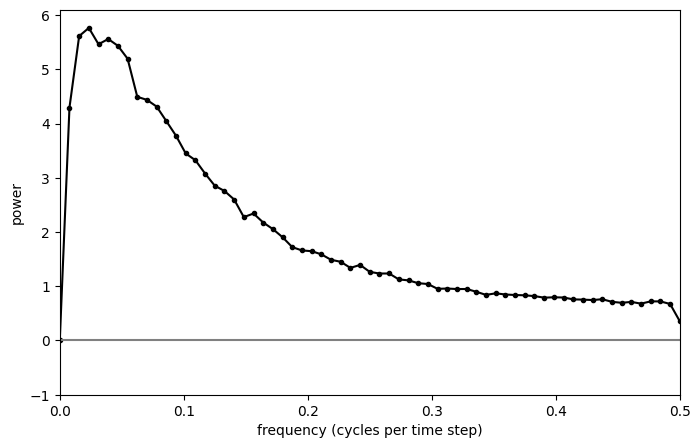

In [3]:
rng = np.random.default_rng(87)

T = 128
N = 1000
alpha = 0.5
factor = np.sqrt(1.0 - alpha * alpha)

x = np.zeros(T * N)
x[0] = factor * rng.normal()
for j in range(1, T * N):
    x[j] = x[j - 1] * alpha + factor * rng.normal()

f, data_spec = sig.welch(
    x, window="boxcar", nperseg=T, noverlap=T / 2, detrend="linear"
)
f, data_spec = plot_normalized_spectrum(f, data_spec)

## Build the sinc kernel for a finite-window boxcar

Now pretend we only have `T = 30` time steps of data. That short boxcar has a sinc-shaped response function. We will convolve the spectrum above with this sinc.

In [4]:
T = 30
omega = np.append([-1.0 * f * 2.0 * np.pi], [f * 2.0 * np.pi])
omega = np.sort(omega)
omega = omega[int(omega.size / 4) : int(3 * omega.size / 4)]

B = np.sinc(omega * T / (2.0 * np.pi))
Cb = np.convolve(data_spec, B / np.sum(B), mode="same")

## Visualize the convolution at one frequency

Drop the sinc kernel at $f = 0.1$ and mark the orange point on the spectrum. The convolution at that frequency is the weighted sum of the spectrum under the sinc.

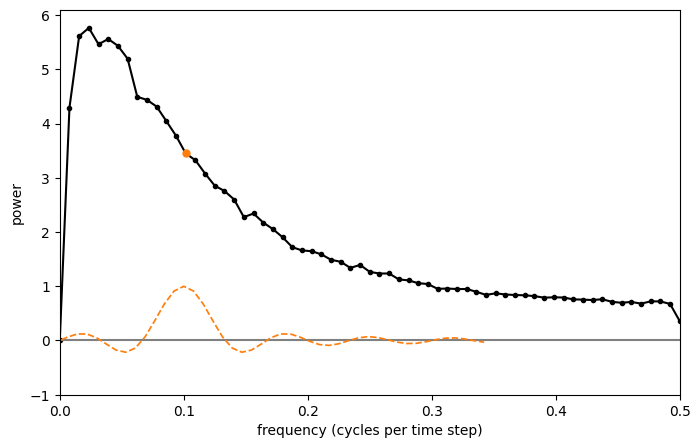

In [5]:
f, data_spec = plot_normalized_spectrum(f, data_spec)

plt.plot(
    omega / (2.0 * np.pi) + 0.1,
    B / np.max(B),
    "--",
    color="tab:orange",
    linewidth=1.25,
    label="response function of rectangular window",
)
j = isclosest(f, 0.1)[1]
plt.plot(f[j], data_spec[j], ".", color="tab:orange", markersize=MS)
plt.show()

Now move the kernel to $f = 0.2$ as well, to drive home that the same kernel is sliding along the frequency axis.

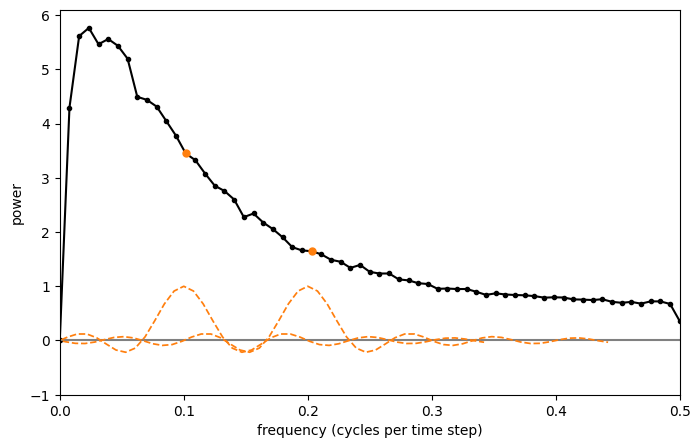

In [6]:
f, data_spec = plot_normalized_spectrum(f, data_spec)
for f0 in (0.1, 0.2):
    plt.plot(
        omega / (2.0 * np.pi) + f0,
        B / np.max(B),
        "--",
        color="tab:orange",
        linewidth=1.25,
    )
    j = isclosest(f, f0)[1]
    plt.plot(f[j], data_spec[j], ".", color="tab:orange", markersize=MS)
plt.show()

One more position, at $f = 0.3$, just to make the pattern obvious.

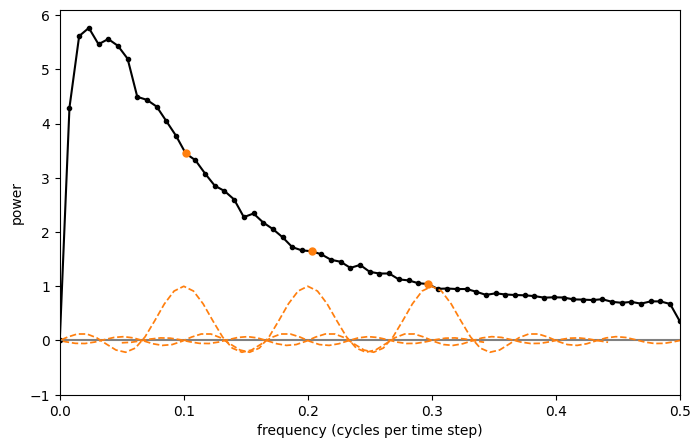

In [7]:
f, data_spec = plot_normalized_spectrum(f, data_spec)
for f0 in (0.1, 0.2, 0.3):
    plt.plot(
        omega / (2.0 * np.pi) + f0,
        B / np.max(B),
        "--",
        color="tab:orange",
        linewidth=1.25,
    )
    j = isclosest(f, f0)[1]
    plt.plot(f[j], data_spec[j], ".", color="tab:orange", markersize=MS)
plt.show()

Now overlay the full convolved spectrum. This is the **observed** spectrum you would actually get from a length-30 sample of an infinite series. The smoothing is forced on you by the finite window — not chosen by you.

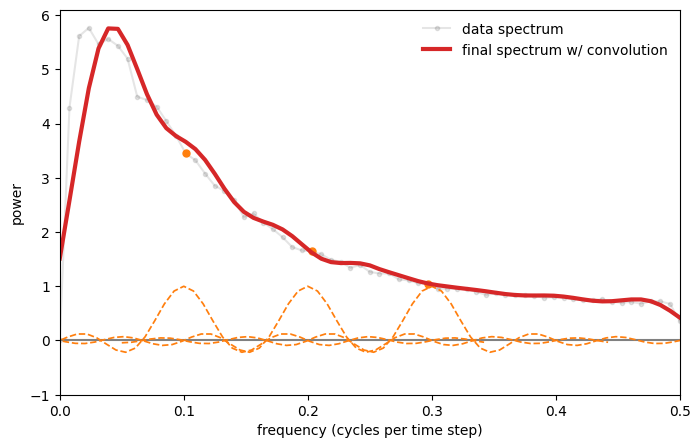

In [8]:
f, data_spec = plot_normalized_spectrum(f, data_spec, alpha=0.1)
for f0 in (0.1, 0.2, 0.3):
    plt.plot(
        omega / (2.0 * np.pi) + f0,
        B / np.max(B),
        "--",
        color="tab:orange",
        linewidth=1.25,
    )
    j = isclosest(f, f0)[1]
    plt.plot(f[j], data_spec[j], ".", color="tab:orange", markersize=MS)
plt.plot(f, Cb, "tab:red", linewidth=3, label="final spectrum w/ convolution")
plt.legend(frameon=False)
plt.show()

## Now experiment with Welch's method

Make a really long red-noise series with a buried cosine and a linear trend, then play with `scipy.signal.welch`. Try changing `N` (number of chunks), `T` (chunk length), the `window`, the `noverlap`, and the `detrend` options.

- [`scipy.signal.welch`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html)
- [`scipy.signal.get_window`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.get_window.html#scipy.signal.get_window)

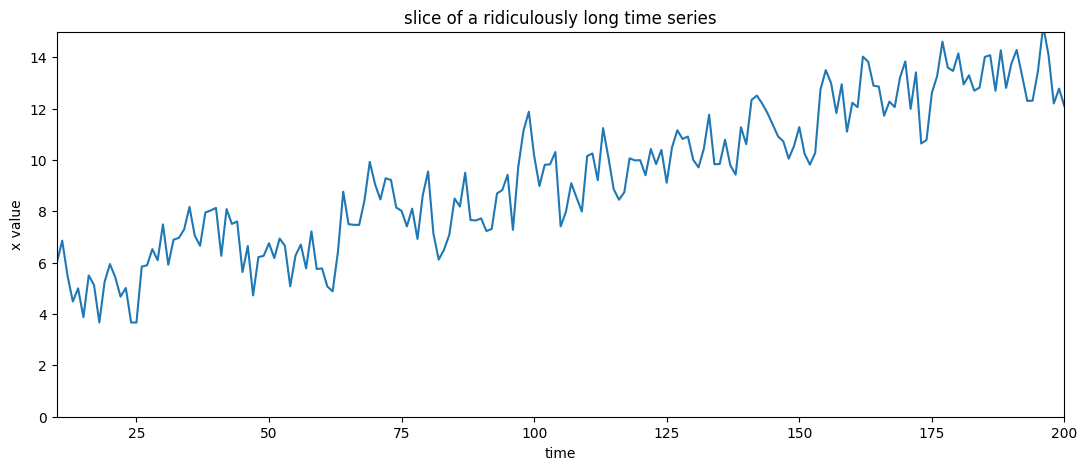

In [9]:
rng = np.random.default_rng(55)
L = 200_000
alpha = 0.5
factor = np.sqrt(1.0 - alpha * alpha)

x = np.zeros(L)
x[0] = factor * rng.normal()
for j in range(1, L):
    x[j] = (
        x[j - 1] * alpha
        + factor * rng.normal()
        + 0.25 * np.cos(2.0 * np.pi * 50.0 / 256.0 * j)
        + 2
    )
x = x + 0.05 * np.arange(x.size)

plt.figure(figsize=(13, 5))
plt.plot(x)
plt.xlim(10, 200)
plt.ylim(0, 15)
plt.xlabel("time")
plt.ylabel("x value")
plt.title("slice of a ridiculously long time series")
plt.show()

Compute spectra two ways — with a boxcar window and with a Hann window plus 50% overlap — and compare.

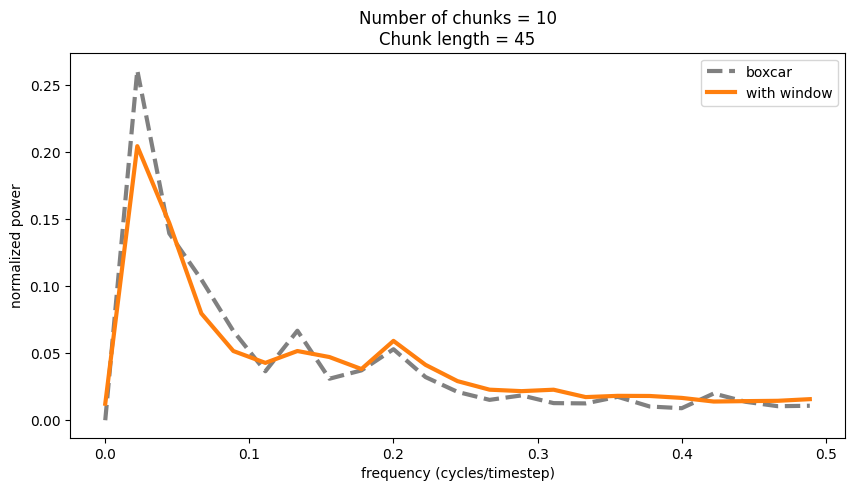

In [10]:
N_chunks = 10  # number of chunks; CHANGE THIS
T_chunk = 45  # length of chunk;  CHANGE THIS

assert N_chunks * T_chunk <= L, "you are requesting too much data."

plt.figure(figsize=(10, 5))

f, spec = sig.welch(
    x[: N_chunks * T_chunk],
    window="boxcar",
    nperseg=T_chunk,
    noverlap=0,
    detrend="constant",
)
plt.plot(f, spec / np.sum(spec), "--", label="boxcar", linewidth=3, color="gray")

f, spec = sig.welch(
    x[: N_chunks * T_chunk],
    window="hann",
    nperseg=T_chunk,
    noverlap=T_chunk / 2,
    detrend="constant",
)
plt.plot(
    f,
    spec / np.sum(spec),
    "-",
    linewidth=3,
    markersize=10,
    color="tab:orange",
    label="with window",
)

plt.ylabel("normalized power")
plt.xlabel("frequency (cycles/timestep)")
plt.legend()
plt.title(f"Number of chunks = {N_chunks}\nChunk length = {T_chunk}")
plt.show()

## Take-home point

Every finite data sample is implicitly multiplied in time by a boxcar. In frequency space this multiplication becomes a convolution with the boxcar's sinc response. The resulting spectrum is smoothed whether you want it to be or not — and is leaked by the sinc's side lobes. Choosing a smoother taper (Hann, Hamming, ...) trades a wider main lobe for far less side-lobe leakage.